# AI534 Implementation Assignment 3###
**Team Members** : Shanmukha Rangeneni, Manogna challoju

**Group: IA3 9**

We have used 2 bonus days for this project

**Deadline**: Sunday, Nov. 17, by 11:59pm

**Submission**: Submit 1) your completed notebook in ipynb format, and 2) a PDF export of the completed notebook with outputs.

**Late Submission**: Please see the syllabus for the late submission policy.

In this assignment, you will use the sklearn package to experiment with Support Vector Machines and Naive Bayes models. The experiments will utilize the validation data to perform parameter tuning, and explore the impact of different parameters on the models' behavior.

You may modify the starter code as you see fit, including changing existing or adding new code blocks. However, please ensure that your modifications are clear so that your TA can easily understand what you are doing and why.

First let's import the packages needed for this assignment.

In [1]:
!pip install nbconvert > /dev/null 2>&1
!pip install pdfkit > /dev/null 2>&1
!apt-get install -y wkhtmltopdf > /dev/null 2>&1
import os
import pdfkit
import contextlib
import sys
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

import seaborn as sns


# Data
The data for this assignment consists of a natural language sentiment dataset sourced from Twitter. The first column indicates sentiment of the tweets (zero representing negative sentiment and one for positive sentiment) and the second column contains the text of the tweets.

Two datasets are provided on Canvas: a training set named 'IA3-training.csv' and a validation set named 'IA3-dev.csv'. You will use the training set to build your models and the validation set to tune the parameters and observe their impacts.

Let's load the data.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

train_path = '/content/gdrive/My Drive/AI534/IA3-train.csv' # DO NOT MODIFY THIS. Please make sure your data has this exact path
val_path = '/content/gdrive/My Drive/AI534/IA3-dev.csv' # DO NOT MODIFY THIS. Please make sure your data has this exact path
train_data = pd.read_csv(train_path)
val_data = pd.read_csv(val_path)

Mounted at /content/gdrive


# Part 0: Preprocessing to form BoW Representation (5 pts)
In this part, you will take the text of the tweets and convert it to the bag-of-words (BoW) representation that can be processed by the model you will train. First, you will build your BoW vocabulary using the training set and represent your training set using *tf-idf*.

Here ***tf*** stands for term frequecy and is defined as follows for a document $d$ and term $t$:

$TF(t,d) = \frac{\mbox{Num. of times } t \mbox{ appears in } d}{\mbox{Total number of terms in }d}$

and ***idf*** stands for inverse document frequency and is defined as follows for a term $t$ and a document collection $D$

$IDF(t, D) = \log(\frac{N}{|\{d\in D: t\in d\}|}) $


where $N$ is the total number of documents in $D$, and $|\{d\in D: t\in d\}|$ is the number of documents that contain term $t$.


Specifically, you will be using the **TfidfVectorizer** class from the sklearn.feature_extraction.text package (https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html#). For this assignment, you should set '***stop_words=english***', other parameters can remain at their default values.

The specific methods you will need to use include:

*   ***fit_transform()***:  You will apply this function to the training text to learn the vocabulary and the inverse document frequency, and generate the tf-idf representation for the training documents.

*   ***transform()***: you will apply this function to the validation text to generate the tf-idf representation for the validation documents, using a vocabulary and inverse document frequency that are already learned from the training data.

Note that both of the above methods return a sparse matrix representation of the documents. This format can be directly used by the SVM package and the Naive Bayes Package for learning. Using a sparse matrix for your document representation is computationally much more efficient, especially for SVM models.

Now let's take a look at the tf-idf representation of your training dataset and see if we can find some useful words to differentiate the two classes of sentiments.
1. For each category ('positive' and 'negative'), compile a list of the top 20 words with the highest cumulative TF-IDF scores across all documents in that category.
2. Compare the two lists and identify a) words that appear in both categories; b) words that are distinctly associated with the 'positive' category; and c) words that are distinctly associated with the 'negative' category.


In [25]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(train_data['text'])
X_train=tfidf_matrix
X_val = vectorizer.transform(val_data['text'])
y_train = train_data['sentiment']
y_val = val_data['sentiment']
feature_names = vectorizer.get_feature_names_out()


positive_indices = train_data.loc[train_data['sentiment'] == 1].index
negative_indices = train_data.loc[train_data['sentiment'] == 0].index

# calculate cumulative TF-IDF scores
def compute_cumulative_tfidf(matrix, indices):
    return matrix[indices].sum(axis=0).A1

# extract top 20 words
def get_top_words(tfidf_scores, feature_names, top_n=20):
    sorted_indices = tfidf_scores.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in sorted_indices]

# Compute scores and extract top words
positive_tfidf_scores = compute_cumulative_tfidf(tfidf_matrix, positive_indices)
negative_tfidf_scores = compute_cumulative_tfidf(tfidf_matrix, negative_indices)

top_positive_words = get_top_words(positive_tfidf_scores, feature_names)
top_negative_words = get_top_words(negative_tfidf_scores, feature_names)

# Identify common and distinct words
common_words = set(top_positive_words) & set(top_negative_words)
dist_positive_words = set(top_positive_words) - common_words
dist_negative_words = set(top_negative_words) - common_words


print(f"Top 20 words in positive tweets: {top_positive_words}")
print(f"Top 20 words in negative tweets: {top_negative_words}")
print(f"Common words in both categories: {common_words}")
print(f"Distinct words associated with positive category only: {dist_positive_words}")
print(f"Distinct words associated with negative category only: {dist_negative_words}")


Top 20 words in positive tweets: ['thanks', 'thank', 'jetblue', 'southwestair', 'united', 'americanair', 'great', 'usairways', 'flight', 'virginamerica', 'http', 'love', 'just', 'awesome', 'best', 'guys', 'service', 'good', 'got', 'appreciate']
Top 20 words in negative tweets: ['flight', 'united', 'usairways', 'americanair', 'southwestair', 'jetblue', 'cancelled', 'service', 'hold', 'hours', 'help', 'customer', 'just', 'time', 'delayed', 'plane', 'flightled', 'hour', 'bag', 'amp']
Common words in both categories: {'flight', 'americanair', 'usairways', 'just', 'southwestair', 'service', 'united', 'jetblue'}
Distinct words associated with positive category only: {'best', 'great', 'good', 'guys', 'http', 'thank', 'love', 'appreciate', 'virginamerica', 'awesome', 'thanks', 'got'}
Distinct words associated with negative category only: {'hour', 'hold', 'amp', 'cancelled', 'delayed', 'customer', 'help', 'hours', 'flightled', 'plane', 'bag', 'time'}


**Question**
1. Examine the words present in each of the three categories: 'common to both categories', 'positive only', and 'negative only'. Describe the nature and characteristics of these words.
2. Reflect on how a linear classification model differentiating the two classes might utilize the words from each category. What are your expectations regarding the sign (positive or negative) and magnitude (size) of the weights that would be assigned to these words by the model?

1.

Common words like *'flight,'* *'americanair,'* and *'service'* are neutral, domain-specific terms associated with airlines and flight experiences. These words frequently appear in both positive and negative tweets due to their broad relevance. Their sentiment is context-dependent; for instance, *'service'* may convey positivity in "great service" or negativity in "worst service experience."

**Positive-Only Words:** Examples: *'best,'* *'great,'* *'love,'* *'awesome.'*  
These words convey gratitude, admiration, or satisfaction, strongly associated with praise. They often highlight good service, appreciation for staff, or exceptional customer experiences.

**Negative-Only Words:** Examples: *'hour,'* *'cancelled,'* *'delayed,'* *'help.'*  
These words express complaints or frustrations, focusing on issues like delays, cancellations, long waits, or poor service. They reflect dissatisfaction and criticism of the airline's operations or customer support.


2. In a linear classification model, the weights for words are determined by how well they distinguish between positive and negative sentiment. **Common words** (e.g., *'flight'*, *'americanair'*) would have small or close to negligible, neutral weights as they appear in both contexts and they donot have much influence on the overall classification due to their neutrality. **Positive-only words** (e.g., *'great'*, *'love'*) would have large positive weights, while **negative-only words** (e.g., *'cancelled'*, *'delayed'*) would have large negative weights due to their strong association with sentiment.


# Part 1. (30 pts) Linear SVM.
Use sklearn to train linear SVMs and tune the hyperparameter $c$ using grid search, considering $c = 10^i$ with $i$ ranging from -2 to 3, based on the validation accuracy. For each $c$ value, please
1. build a linear SVM model using the svm.SVC class
2. record the total number of support vectors of your model
3. evaluate the model's accuracy on the training data and validation data respectively.


Please produce the following two plots:
1.   Accuracy vs. $c$. In this plot, please plot both the training and validation accuracy as a function of the $c$ parameter (using log scale for $c$)
2.   Number of support vectors vs. $c$. In this plot, please plot the # of total support vectors for your SVM mdoel as a function of the $c$ parameter (using log scale for $c$).

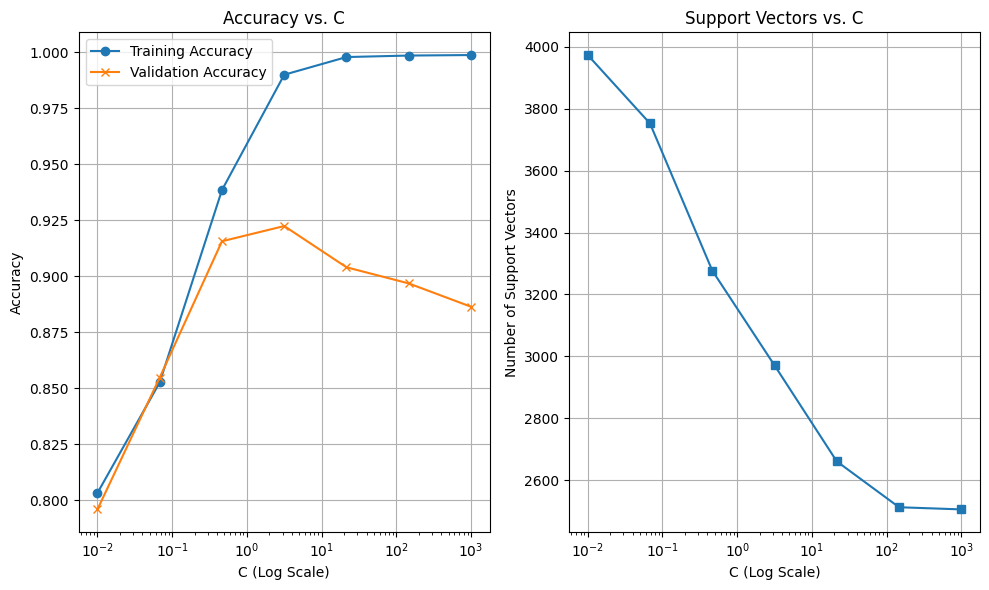

In [26]:


train_accuracies = []
val_accuracies = []
support_vectors_count = []

# Generate C values using logarithmic scale (10^i for i from -2 to 3)
C_range = np.logspace(-2, 3, 7)

for C_val in C_range:
    # Create and train the linear SVM model
    svm_model = svm.SVC(kernel='linear', C=C_val)
    svm_model.fit(X_train, y_train)

    # Count the number of support vectors
    support_vectors_count.append(svm_model.support_.shape[0])

    # Calculate accuracies on training and validation data
    train_acc = svm_model.score(X_train, y_train)
    val_acc = svm_model.score(X_val, y_val)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

# Plotting Results
plt.figure(figsize=(10, 6))

# Plot: Accuracy vs. C
plt.subplot(1, 2, 1)
plt.plot(C_range, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(C_range, val_accuracies, label='Validation Accuracy', marker='x')
plt.xscale('log')
plt.xlabel('C (Log Scale)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. C')
plt.legend()
plt.grid(True)

# Plot: Number of Support Vectors vs. C
plt.subplot(1, 2, 2)
plt.plot(C_range, support_vectors_count, marker='s')
plt.xscale('log')
plt.xlabel('C (Log Scale)')
plt.ylabel('Number of Support Vectors')
plt.title('Support Vectors vs. C')
plt.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show plots
plt.show()


**Question**
1. What trend do you theoretically expect to see for training and validation performance as we increase $c$? Why? Does the observed behavior match your expectation? If not, can you provide some explanation?
2. What trend do you theoretically expect to see for the number of support vectors as we increase $c$? Why? Does the observed behavior match your expectation? If not, can you provide some explanation?  



1. **Training and Validation Performance as C Increases:**
   - **Training Performance:** As C increases, the model becomes more sensitive to misclassification, leading to lower training error and higher training accuracy.
   - **Validation Performance:** Initially, increasing C reduces underfitting, improving validation accuracy. However, if C is too large, overfitting may occur, causing validation accuracy to drop.

   **Observed Behavior:**
   Training accuracy is increasing as C grows which align with my expectations

   Validation accuracy improves at first but plateaus/drops off slightly which shows signs of overfitting. This behviour also meets with theory

2. **Number of Support Vectors as C Increases:**

**Theoretical Expectation**: As C increases, the SVM model becomes more stringent in minimizing misclassification, leading to a decrease in the number of support vectors. With smaller values of
C, the model tolerates more margin violations, requiring more support vectors.

**Observed Behavior**: The number of support vectors initially increases as C rises, then sharply decreases at very high values of C. This increase may seem counterintuitive but could be due to specific data distribution, where intermediate C values find a balance allowing many support vectors near the decision boundary. This aligns wiht my theoritical expectation.
At very high C values, the model tightens the margin and becomes more selective, reducing the number of support vectors, aligning with the theoretical expectation. The sharp decrease in support vectors at high C values suggests the model is focusing on a smaller subset of critical data points, such as outliers, to define the decision boundary.



Expand your search beyond the grid search for the parameter $c$.
Here is the basic instruction:
* **Boundary Expansion**: If the best-performing parameter choice is located at the edge of your current grid search range, extend this boundary outward. This approach helps to explore whether even better-performing parameters exist beyond the existing limits of your grid.

* **Grid Refinement for Central Optima**: When the optimal parameter choice lies within the middle of your search grid, focus on refining the grid around this optimum. For instance, if your current best result is at $i=1$, consider adding intermediate points near the current best such as $i=0.5$ and $1.5$ to your search. This targeted refinement helps in achieving a more precise determination of the optimum within the identified range.

Additionally, apply these strategies iteratively can further improver the results. If subsequent searches reveal new boundaries or central optima, repeat the expansion or refinement process to continually hone in on the most effective parameters.



In [27]:
from sklearn import svm
from sklearn.metrics import accuracy_score
import numpy as np


def train_and_evaluate(X_train, y_train, X_val, y_val, c_value):
    model = svm.SVC(kernel="linear", C=c_value)
    model.fit(X_train, y_train)
    validation_accuracy = accuracy_score(y_val, model.predict(X_val))
    return model, validation_accuracy

#perform grid search over C values
def grid_search(X_train, y_train, X_val, y_val, c_range):
    best_c = None
    highest_accuracy = 0

    for c_value in c_range:
        _, val_accuracy = train_and_evaluate(X_train, y_train, X_val, y_val, c_value)

        if val_accuracy > highest_accuracy:
            highest_accuracy = val_accuracy
            best_c = c_value

    return best_c, highest_accuracy

#refine or expand the C range
def adjust_c_range(optimal_c, original_range, is_expanding=False):
    log_c = np.log10(optimal_c)
    if is_expanding:
        if optimal_c == min(original_range):
            return np.logspace(log_c - 1, log_c, 3)
        if optimal_c == max(original_range):
            return np.logspace(log_c, log_c + 1, 3)
    return np.logspace(log_c - 0.5, log_c + 0.5, 5)

# train the final model and evaluate performance
def evaluate_final_model(X_train, y_train, X_val, y_val, optimal_c):
    model = svm.SVC(kernel="linear", C=optimal_c)
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    val_accuracy = model.score(X_val, y_val)
    num_support_vectors = len(model.support_)

    return train_accuracy, val_accuracy, num_support_vectors

# Main function
def main_grid_search(X_train, y_train, X_val, y_val):
    initial_c_range = np.logspace(-2, 3, 7)
    optimal_c, best_accuracy = grid_search(X_train, y_train, X_val, y_val, initial_c_range)

    # Determine if boundaries need expansion or refinement
    is_boundary = optimal_c == min(initial_c_range) or optimal_c == max(initial_c_range)
    refined_c_range = adjust_c_range(optimal_c, initial_c_range, is_expanding=is_boundary)
    optimal_c, best_accuracy = grid_search(X_train, y_train, X_val, y_val, refined_c_range)
    train_accuracy, val_accuracy, num_support_vectors = evaluate_final_model(X_train, y_train, X_val, y_val, optimal_c)

    print(f"Optimal C: {optimal_c}")
    print(f"Best Validation Accuracy: {best_accuracy}")
    print(f"Training Accuracy: {train_accuracy}")
    print(f"Validation Accuracy: {val_accuracy}")
    print(f"Number of Support Vectors: {num_support_vectors}")

main_grid_search(X_train, y_train, X_val, y_val)


Optimal C: 1.7782794100389228
Best Validation Accuracy: 0.9252
Training Accuracy: 0.9832222222222222
Validation Accuracy: 0.9252
Number of Support Vectors: 3046


**Question:**
What is the best validation performance you are able to achieve using linear SVM on this dataset? What $c$ value is used?


The best validation accuracy i got is 0.9252(92.52%) for optimal C value around 1.778

For the best performing linear SVM model that you built, identify and report the ten words with the highest positive weight coefficients and the ten words with the highest negative weight coefficients, separately.

In [9]:
def display_top_terms(model, vectorizer, top_n=10):
    Weights = model.coef_.toarray().flatten()
    feature_names = vectorizer.get_feature_names_out()

    # zip features with their corresponding weights
    feature_weights = list(zip(feature_names, Weights))
    sorted_features = sorted(feature_weights, key=lambda x: x[1])

    # Get top positive and negative features
    top_positive = sorted_features[-top_n:][::-1]
    top_negative = sorted_features[:top_n]
    positive_terms = ', '.join([f"{feature} ({weight:.4f})" for feature, weight in top_positive])
    negative_terms = ', '.join([f"{feature} ({weight:.4f})" for feature, weight in top_negative])

    print("Top 10 Words with High Positive Weights:")
    print(f"{{ {positive_terms} }}\n")

    print("Top 10 Words with High Negative Weights:")
    print(f"{{ {negative_terms} }}")

display_top_terms(final_model, vectorizer)


Top 10 Words with High Positive Weights:
{ thank (5.3644), thanks (4.9280), awesome (3.7439), great (3.6134), kudos (3.4371), love (3.0957), excellent (2.9079), amazing (2.8387), best (2.6942), appreciate (2.4196) }

Top 10 Words with High Negative Weights:
{ worst (-3.0655), hold (-2.8094), hours (-2.6012), hour (-2.3164), website (-2.2812), luggage (-2.2060), delayed (-2.1332), paid (-1.8712), delay (-1.8156), sit (-1.7973) }


**Question**
Compare these two lists of words with the lists you compiled in part 0. Discuss the reasons why some words from the earlier lists might not have appeared in these new lists.

The words with high positive and negative weights largely align with the earlier categorized words. Positive-weighted words "like thank, awesome, and love" match the Positive-Only Words list, reflecting strong positive sentiment. Negative-weighted words like worst, delayed align with the Negative-Only Words list, indicating dissatisfaction.

However, neutral, domain-specific words like flight and service don’t appear in the high weight lists, as they don’t inherently carry sentiment and likely have neutral weights.

The difference comes from how TF-IDF and SVM work. TF-IDF highlights words that are important and appear frequently, so common words like *flight* and *service* show up more. On the other hand, SVM focuses on words that clearly show positive or negative feelings, like *great* or *delayed*, because they help classify sentiment better. TF-IDF looks at overall importance, while SVM picks words that are most useful for telling positive and negative apart.

# Part 2. (35 pts) SVM with RBF kernel

Use sklearn to train SVMs with RBF kernel and tune the hyperparameters $c$ and $\gamma$ ($\gamma=1/\sigma^2$ in the RBF kernel definition provided in the lecture slides) using grid search based on the validation accuracy. For $c$, please search over $c = 10^i$ with $i$ ranging from $-2$ to $3$. For $\gamma$, please search over $\gamma=10^{i}$ with $i$ ranging from -3 to 1.  For each $c$ and $\gamma$ value combination, please
1. build a SVM model using the svm.SVC class with kernel="rbf"
2. record the total number of support vectors of your model
3. evaluate the model's accuracy on the training data and validation data respectively.


Please plot the training accuracy, validation accuracy, and the number of support vectors as function of $c$ and $\gamma$ using the heatmap function from the seaborn package (https://seaborn.pydata.org/generated/seaborn.heatmap.html). Please use 'annot=True' and specify appropriate format to ensure the annotation can be easily read on the heatmap.


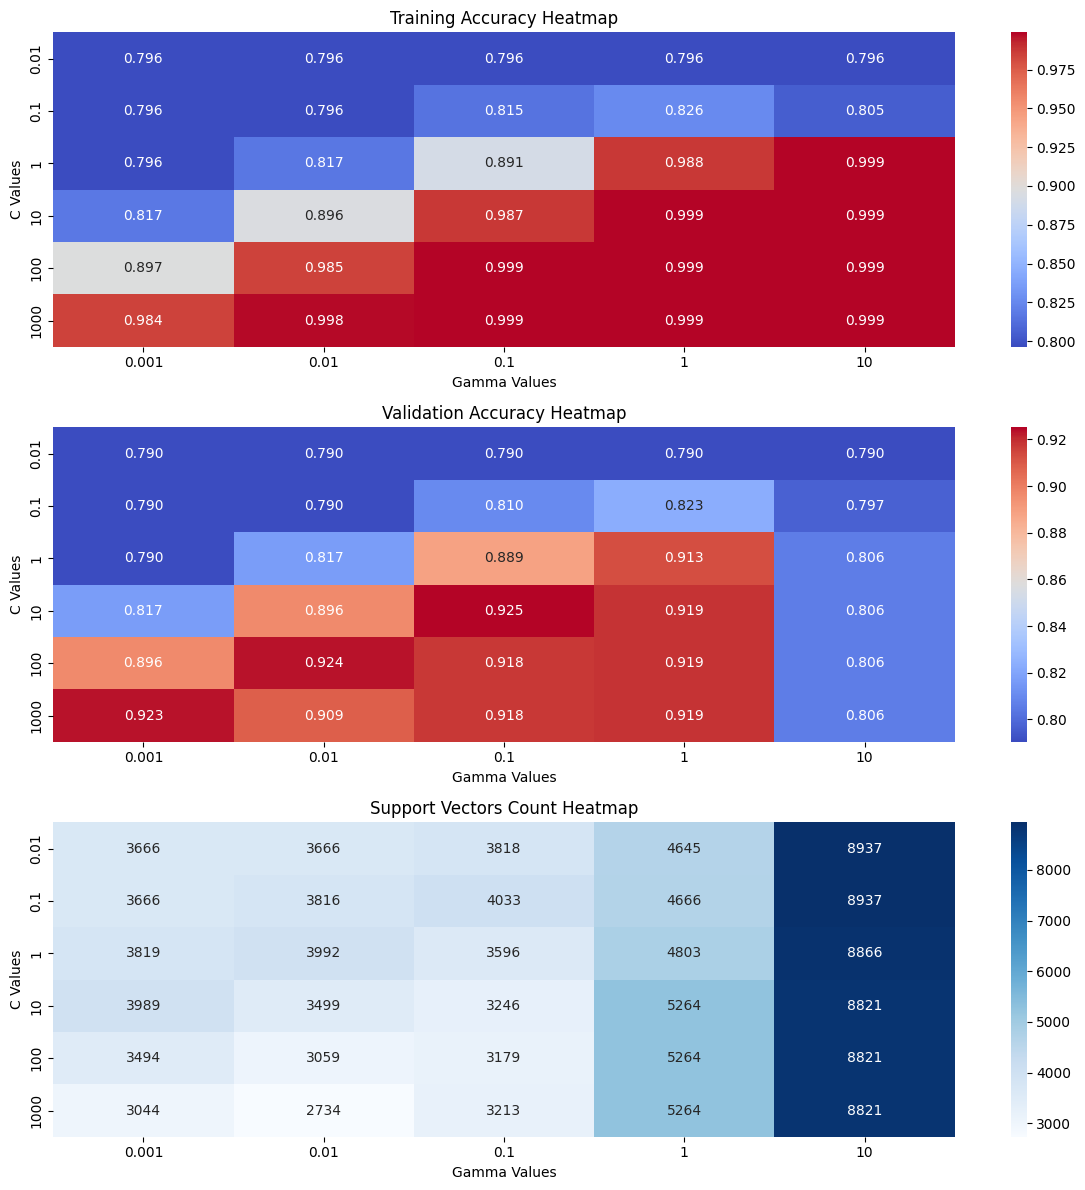

In [28]:

def perform_grid_search(X_train, y_train, X_val, y_val, C_values, gamma_values):
    accuracy_metrics = {
        "train_accuracy": np.zeros((len(C_values), len(gamma_values))),
        "val_accuracy": np.zeros((len(C_values), len(gamma_values))),
        "support_vectors": np.zeros((len(C_values), len(gamma_values))),
    }

    for C_idx, C in enumerate(C_values):
        for gamma_idx, gamma in enumerate(gamma_values):
            # Initialize and train the SVM model with RBF kernel
            model = svm.SVC(kernel='rbf', C=C, gamma=gamma)
            model.fit(X_train, y_train)

            # Store results in dictionary
            accuracy_metrics["train_accuracy"][C_idx, gamma_idx] = model.score(X_train, y_train)
            accuracy_metrics["val_accuracy"][C_idx, gamma_idx] = model.score(X_val, y_val)
            accuracy_metrics["support_vectors"][C_idx, gamma_idx] = len(model.support_)

    return accuracy_metrics

# plot heatmaps
def plot_heatmaps(accuracy_metrics, C_values, gamma_values):
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    sns.heatmap(accuracy_metrics["train_accuracy"], annot=True, fmt=".3f", xticklabels=gamma_values, yticklabels=C_values, cmap="coolwarm", ax=axes[0])
    axes[0].set_title('Training Accuracy Heatmap')
    axes[0].set_xlabel('Gamma Values')
    axes[0].set_ylabel('C Values')
    sns.heatmap(accuracy_metrics["val_accuracy"], annot=True, fmt=".3f", xticklabels=gamma_values, yticklabels=C_values, cmap="coolwarm", ax=axes[1])
    axes[1].set_title('Validation Accuracy Heatmap')
    axes[1].set_xlabel('Gamma Values')
    axes[1].set_ylabel('C Values')
    sns.heatmap(accuracy_metrics["support_vectors"], annot=True, fmt=".0f", xticklabels=gamma_values, yticklabels=C_values, cmap="Blues", ax=axes[2])
    axes[2].set_title('Support Vectors Count Heatmap')
    axes[2].set_xlabel('Gamma Values')
    axes[2].set_ylabel('C Values')
    plt.tight_layout()
    plt.show()

# Main section
def main(X_train, y_train, X_val, y_val):
    C_range = [10 ** i for i in range (-2,4)]
    gamma_range = [10 ** i for i in range (-3,2)]
    # grid search
    accuracy_metrics = perform_grid_search(X_train, y_train, X_val, y_val, C_range, gamma_range)
    plot_heatmaps(accuracy_metrics, C_range, gamma_range)


main(X_train, y_train, X_val, y_val)



**Question**
1. From a theoretical perspective, how would you expect the parameters $c$ and $\gamma$ to influence the model's ability to overfit to the training data? Based on this perspective, how would you expect the training accuracy to change as you change $c$ (keeping $\gamma$ constant), and as you change $\gamma$ (keeping $c$ constant)? Are there any discrepancies between the expected and observed trends? If so, provide some possible explanations for the discrepancies.

2. Similarly, how would you expect the validation accuracy to change as you change $c$ (keeping $\gamma$ constant) and as you change $\gamma$ (keeping $c$ constant)? Are there any discrepancies between the expected and observed trends? If so, please provide some possible explanations for the differences.

3. From a theoretical perspective, how would you expect the parameters $c$ and $\gamma$ influence the number of support vectors? Are there any discrepencies between the expected and observed trends?  If so, provide some possible explanations for the differences.


1. **Effect of C and 𝛾 on Overfitting:**
   - **Theory:** Increasing C makes the model prioritize correctly classifying training data, which can lead to overfitting. Similarly, higher 𝛾 values create a tighter decision boundary that may overfit to the training data.
   - **Training Accuracy:** Higher C and 𝛾 are expected to increase training accuracy as the model becomes stricter about errors and more sensitive to the data.
   - **Discrepancies:** The training accuracy heatmap mostly follows this pattern, but at very high 𝛾, accuracy stops improving. This might be because the model becomes too focused on noise, which doesn't help true predictive performance.

2. **Validation Accuracy:**
   - **Theory:** Validation accuracy typically peaks at moderate values of C and 𝛾. Low values lead to underfitting, while very high values cause overfitting.
   - **Observed Trends:** The heatmap shows maximum validation accuracy at intermediate C and 𝛾, as expected. However, at the highest tested 𝛾, accuracy doesn’t drop much. This could mean the tested range of 𝛾 didn’t reach extreme overfitting, or the validation set resembles the training data closely, hiding overfitting effects.

3. **Number of Support Vectors:**
   - **Theory:** Lower C allows more margin violations, increasing the number of support vectors. Higher 𝛾 makes the decision boundary more complex, potentially requiring more support vectors.
   - **Observed Trends:** Support vector counts decrease as C increases, aligning with theory. However, for 𝛾, the number doesn’t consistently rise at high values. This could happen because overly complex boundaries focus on only a few critical points or due to unique characteristics of the dataset.  


Expand your search using the strategy introduced in part 1 to search for the $c$ and $\gamma$ values that leads to the highest validation accuracy on this data set. Please report the best validation accuracy you achieve and the corresponding $c$ and $\gamma$ values used.

In [30]:

def grid_search_for_best_params(train_features, train_labels, val_features, val_labels, C_range, gamma_range):
    highest_accuracy = 0
    optimal_params = {'C': None, 'gamma': None}

    for C in C_range:
        for gamma in gamma_range:
            model = svm.SVC(kernel='rbf', C=C, gamma=gamma)
            model.fit(train_features, train_labels)

            # Get validation accuracy
            val_accuracy = accuracy_score(val_labels, model.predict(val_features))
            if val_accuracy > highest_accuracy:
                highest_accuracy = val_accuracy
                optimal_params['C'] = C
                optimal_params['gamma'] = gamma

    return optimal_params, highest_accuracy


def refine_search_grid(best_value, current_grid, is_C_param=True):
    if best_value == min(current_grid):
        refined_values = np.logspace(np.log10(best_value) - 1, np.log10(best_value), num=3)
    elif best_value == max(current_grid):
        refined_values = np.logspace(np.log10(best_value), np.log10(best_value) + 1, num=3)
    else:
        base_log_value = np.log10(best_value)
        refined_values = np.logspace(base_log_value - 0.5, base_log_value + 0.5, num=5)

    return refined_values

# Initial grid search over C and gamma values
C_range_initial = [10 ** i for i in range(-2, 4)]
gamma_range_initial = [10 ** i for i in range(-3, 2)]

optimal_params, best_accuracy = grid_search_for_best_params(
    X_train, y_train, X_val, y_val, C_range_initial, gamma_range_initial
)

iterations = 3
for _ in range(iterations):
    C_range_refined = refine_search_grid(optimal_params['C'], C_range_initial, is_C_param=True)
    gamma_range_refined = refine_search_grid(optimal_params['gamma'], gamma_range_initial, is_C_param=False)

    # Update the search grid values
    C_range_initial = C_range_refined
    gamma_range_initial = gamma_range_refined

    # refine grid search
    optimal_params, best_accuracy = grid_search_for_best_params(
        X_train, y_train, X_val, y_val, C_range_initial, gamma_range_initial
    )

print(f"Best Validation Accuracy: {best_accuracy}")
print(f"Optimal Parameters: C = {optimal_params['C']}, gamma = {optimal_params['gamma']}")


Best Validation Accuracy: 0.9272
Optimal Parameters: C = 5.623413251903491, gamma = 0.1778279410038923


# Part 3: (30 pts) Naive Bayes Classifier

In this part, you will use the same TF-IDF representation of the documents and experiment with MultiNomial Naive Bayes classifier to tune the smoothing parameter $\alpha$. Please consider the following initial values for $\alpha$: [2, 1, 0.5, 0.1, 0.05, 0.01]

For each of the $\alpha$ value, please
1. build a multinomial Naive Bayes model using the MultinomialNB class in the sklearn.naive_bayes package
2. evaluate the model's accuracy on the training data and validation data respectively.

For results, please
1. plot the training and validation accuracy as a function of $\alpha$ (using log scale).
2. print out the best training accuracy with its corresponding $\alpha$ and the best validation accuracy with its corresponding $\alpha$.

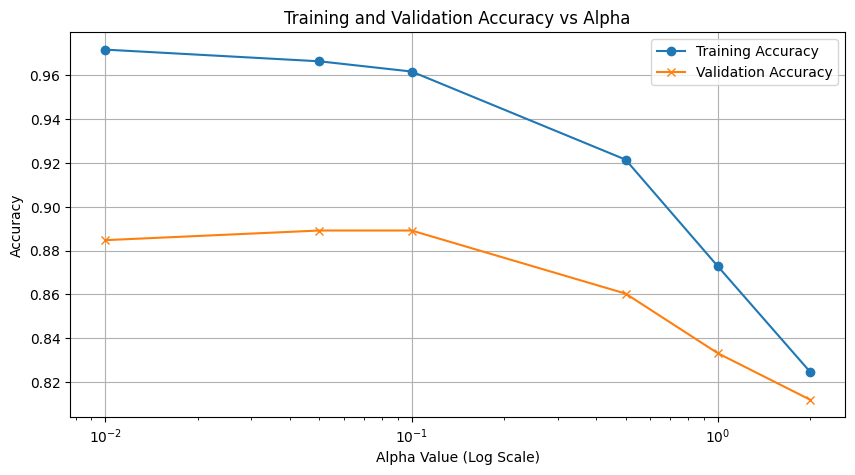

Best Training Accuracy: 0.9718 with alpha = 0.01
Best Validation Accuracy: 0.8892 with alpha = 0.1


In [24]:

alpha_range = [2, 1, 0.5, 0.1, 0.05, 0.01]
train_accuracy_results = []
validation_accuracy_results = []

# Iterate over the different alpha values
for alpha_value in alpha_range:
    model = MultinomialNB(alpha=alpha_value)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    train_accuracy_results.append(train_accuracy)
    validation_accuracy = accuracy_score(y_val, model.predict(X_val))
    validation_accuracy_results.append(validation_accuracy)

# Plot the training and validation accuracy against alpha values
plt.figure(figsize=(10, 5))
plt.plot(alpha_range, train_accuracy_results, label='Training Accuracy', marker='o', linestyle='-')
plt.plot(alpha_range, validation_accuracy_results, label='Validation Accuracy', marker='x', linestyle='-')
plt.xscale('log')
plt.xlabel('Alpha Value (Log Scale)')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs Alpha')
plt.legend()
plt.grid(True)
plt.show()


optimal_train_alpha = alpha_range[np.argmax(train_accuracy_results)]
optimal_validation_alpha = alpha_range[np.argmax(validation_accuracy_results)]
print(f"Best Training Accuracy: {max(train_accuracy_results):.4f} with alpha = {optimal_train_alpha}")
print(f"Best Validation Accuracy: {max(validation_accuracy_results):.4f} with alpha = {optimal_validation_alpha}")


**Question**
Theoretically, how do you expect changing the $\alpha$ parameter influence overfitting for Naive Bayes model?
Based on this perspective, how do you expect the training and validation accuracy to change as we change $\alpha$? Are there any discrepancies between the expected and observed trends? If so, can you propose some possible explanations for these differences?

The smoothing parameter 𝛼 in Naive Bayes helps prevent zero probabilities for unseen features.

1. **Low 𝛼 values (close to 0):** The model relies heavily on the training data, which can lead to overfitting. This occurs when features in the training set are not present in the test or validation sets, causing the model to perform poorly on new data.
  
2. **High 𝛼 values:** The model assumes all features have a minimum frequency, helping it handle rare or unseen features. This reduces overfitting by preventing the model from overemphasizing features that are specific to the training data.

**Expectations for Training and Validation Accuracy:**

- As 𝛼 increases, training accuracy is expected to decrease slightly because the model becomes less focused on the specific details of the training data.
- Validation accuracy is expected to improve with a small increase in 𝛼, as the model generalizes better and is less affected by missing features in the validation set. However, if 𝛼 becomes too large, the model may underfit, leading to a decrease in validation accuracy as it becomes too simple and less sensitive to the data.

**Observed Trends:**

- The graph shows that training accuracy decreases with increasing 𝛼, which aligns with the expectations that the model becomes more generalized.
- However, the validation accuracy also decreases as 𝛼 increases, indicating that even smaller values of 𝛼 are too high, causing the model to underfit.

**Possible Explanations for Discrepancies:**
- Normally, validation accuracy improves with small 𝛼 increases, but here it decreases, indicating that the optimal 𝛼 is likely lower than the smallest value tested. This may suggest the training and validation sets are very similar.
- The Naive Bayes model may be robust for this dataset, so smoothing has little effect, which is why validation accuracy doesn’t improve as expected.

Expand your search using the strategy introduced in part 1 to search for the $\alpha$ that leads to the highest validation accuracy on this data set.
Please report the best validation accuracy you achieve and the corresponding $\alpha$ value used.

Best refined val accuracy: 0.8892
Optimal alpha from refined search: 0.05


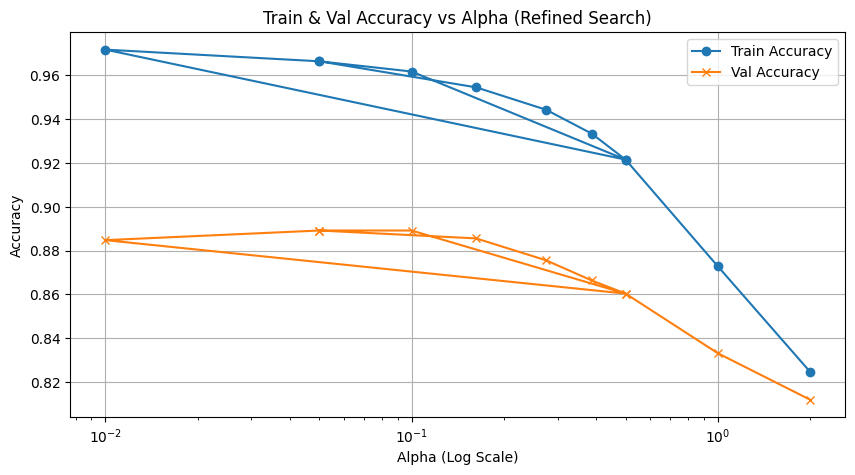

In [23]:
alphas = [2, 1, 0.5, 0.1, 0.05, 0.01]

def evaluate_model(a, X_train, y_train, X_val, y_val):
    model = MultinomialNB(alpha=a)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    return train_acc, val_acc

train_accs, val_accs = [], []

for a in alphas:
    t_acc, v_acc = evaluate_model(a, X_train, y_train, X_val, y_val)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

opt_idx = np.argmax(val_accs)
opt_alpha = alphas[opt_idx]
if opt_idx == 0 or opt_idx == len(alphas) - 1:
    refined_alphas = np.linspace(alphas[0] / 10, alphas[-1] * 10, 5)
else:
    refined_alphas = np.linspace(alphas[opt_idx - 1], alphas[opt_idx + 1], 5)

refined_train_accs, refined_val_accs = [], []

for a in refined_alphas:
    t_acc, v_acc = evaluate_model(a, X_train, y_train, X_val, y_val)
    refined_train_accs.append(t_acc)
    refined_val_accs.append(v_acc)

best_refined_idx = np.argmax(refined_val_accs)
best_alpha = refined_alphas[best_refined_idx]
best_val_acc = refined_val_accs[best_refined_idx]
print(f"Best refined val accuracy: {best_val_acc:.4f}")
print(f"Optimal alpha from refined search: {best_alpha}")

plt.figure(figsize=(10, 5))
plt.plot(alphas + list(refined_alphas), train_accs + refined_train_accs, label='Train Accuracy', marker='o')
plt.plot(alphas + list(refined_alphas), val_accs + refined_val_accs, label='Val Accuracy', marker='x')
plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Accuracy')
plt.title('Train & Val Accuracy vs Alpha (Refined Search)')
plt.legend()
plt.grid(True)
plt.show()


As discussed in class, the multinomial naive bayes classifier learns a linear classifier where the weight coeffcient for each word $i$ can be computed as follows:

$\log P(w_i|y=1) - \log P(w_i|y=0)$

where $P(w_i|y=c)$ denotes the probability for word $i$ when $y=c$. In sklearn, you can access $\log P(w_i|y=1)$ via the feature_log_prob_ attribute of the MultinomialNB class.

Examine two naive bayes models: one with $\alpha =1$, the other with the best $\alpha$ you identified above. For each model, identify the top 10 words with the highest positive weights and the top 10 words with the highest negative weights, and print them along with their corresponding weight values.


In [22]:

def top_words(alpha, X, y, feats):
    model = MultinomialNB(alpha=alpha)
    model.fit(X, y)
    log_diff = model.feature_log_prob_[1] - model.feature_log_prob_[0]

    # Sort and select top 10 positive and negative words
    idx_sorted = np.argsort(log_diff)
    pos_idx = idx_sorted[-10:]
    neg_idx = idx_sorted[:10]

    pos_words = [(feats[i], log_diff[i]) for i in pos_idx]
    neg_words = [(feats[i], log_diff[i]) for i in neg_idx]

    return pos_words, neg_words


feats = vectorizer.get_feature_names_out()

# Get top words for alpha = 1
pos_1, neg_1 = top_words(1, X_train, y_train, feats)
print("Alpha = 1:")
print("Top 10 words with highest positive weights", pos_1)
print("Top 10 words with highest negative weights:", neg_1)

pos_best, neg_best = top_words(best_refined_alpha, X_train, y_train, feats)
print(f"Alpha = {best_refined_alpha}:")
print("Top 10 words with highest positive weights", pos_best)
print("Top 10 words with highest negative weights:", neg_best)


Alpha = 1:
Top 10 words with highest positive weights [('passbook', 2.129243170273295), ('amazing', 2.2378256417964746), ('kudos', 2.2552462975829073), ('outstanding', 2.2774735424529595), ('rock', 2.3658824868683777), ('favorite', 2.3865097990131208), ('imaginedragons', 2.4421102524663247), ('fortunemagazine', 2.473274677665928), ('awesome', 2.4953873957134), ('thank', 2.8844084732627095)]
Top 10 words with highest negative weights: [('worst', -3.3531344895289728), ('hours', -3.2625174133504133), ('hold', -3.076962407390657), ('online', -2.6492995076374175), ('hrs', -2.6215638765711917), ('rude', -2.620176108777578), ('ridiculous', -2.5174182505689275), ('delayed', -2.4968107888634297), ('pay', -2.4762753986079558), ('stuck', -2.4727924223353064)]
Alpha = 0.05:
Top 10 words with highest positive weights [('exceptional', 5.132513685225105), ('lauren', 5.149147441343317), ('dancing', 5.1500105151598925), ('love_dragonss', 5.341345211714649), ('smooth', 5.346613809523523), ('aww', 5.4282

**Question**
1. Comparing the list of words and their weights of the two Naive Bayes models. Discuss any noticeable trends or differences in the weights in relation to the $\alpha$ value. Provide your explanation for this trend.
2. Compare the list of words and their weights from your best performing Naive Bayes model, with those from the best linear SVM model in part 1. Discuss any noticeable differences between the two models. How do you think the differences influence the model's ability to generalize.

1. **Weight Trends with Changes in $\alpha$:**
   - When $\alpha = 1$, the weights are moderate. Reducing $\alpha$ to 0.05 increases the extremes in the weights (both positive and negative).
   - Smaller $\alpha$ values make the model more sensitive to the training data, resulting in larger weight differences between classes. Larger $\alpha$ values smooth out these differences, leading to smaller weights.
   - This happens because a smaller $\alpha$ reduces smoothing, allowing the model to more strongly distinguish words that are characteristic of one class.

2. **Comparison with Linear SVM Weights:**
   - Naive Bayes and SVM models may identify similar words if those words are key indicators of sentiment. However, SVM weights focus on maximizing the margin between classes, while Naive Bayes weights are based on the likelihood of word occurrences within each class.
   - Naive Bayes assumes feature independence, which can lead to more extreme weights for strongly class-associated words. SVM captures more complex patterns, handling feature interactions better.
   - SVMs may generalize better when features are correlated, while Naive Bayes can perform well when the independence assumption holds or with large, sparse datasets.
   - The words and weights show what each model considers important for sentiment, with SVM often identifying a more nuanced set of features, and Naive Bayes focusing on extreme weights for more polarized words.

The variations in weights between the two models, as well as within Naive Bayes models with different $\alpha$ values, can greatly influence the models' performance and their ability to generalize to new, unseen data. Understanding these differences is essential for choosing the appropriate model and parameters for a specific task

In [33]:
#running this code block will convert this notebook and its outputs into a pdf report.
!jupyter nbconvert --to html /content/gdrive/MyDrive/Colab\ Notebooks/IA3-2024.ipynb  # you might need to change this path to appropriate value to location your copy of the IA0 notebook

input_html = '/content/gdrive/MyDrive/Colab Notebooks/IA3-2024.html' #you might need to change this path accordingly
output_pdf = '/content/gdrive/MyDrive/Colab Notebooks/IA3output.pdf' #you might need to change this path or name accordingly

# Convert HTML to PDF
pdfkit.from_file(input_html, output_pdf)

# Download the generated PDF
files.download(output_pdf)

[NbConvertApp] Converting notebook /content/gdrive/MyDrive/Colab Notebooks/IA3-2024.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 807621 bytes to /content/gdrive/MyDrive/Colab Notebooks/IA3-2024.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>